# Proyecto MLE - Riesgo Crediticio - Jorge Sialer
## Fase 1: Análisis Exploratorio de Datos (EDA) y Preprocesamiento

El objetivo de este notebook es entender la estructura de los datos, identificar problemas de calidad (valores nulos, duplicados, valores atípicos) y preparar el conjunto de datos para el entrenamiento de los modelos de Machine Learning.

In [10]:
# Importaciones base para análisis exploratorio y manipulación
import pandas as pd
import numpy as np

# Importaciones para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica de gráficos basada en tus apuntes
plt.style.use('seaborn-v0_8-darkgrid')

In [11]:
# 1. Cargar los datos
# Asegúrate de que el nombre coincida con el que descargaste en la carpeta data
df = pd.read_csv('../data/loan_risk_prediction_dataset.csv')

# 2. Vista rápida de los primeros registros
print("Primeras 5 filas del dataset:")
display(df.head())

# 3. Información general (tipos de variables y nulos)
print("\n--- Información del Dataset ---")
df.info()

# 4. Estadísticas descriptivas de las variables numéricas
print("\n--- Estadísticas Descriptivas ---")
display(df.describe())

# 5. Revisión de valores nulos y duplicados
print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum())

print(f"\nTotal de filas duplicadas: {df.duplicated().sum()}")

Primeras 5 filas del dataset:


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0



--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   str    
 6   Education        4802 non-null   str    
 7   City             5000 non-null   str    
 8   EmploymentType   5000 non-null   str    
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 390.8 KB

--- Estadísticas Descriptivas ---


,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000



--- Conteo de Valores Nulos ---
Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

Total de filas duplicadas: 0


### 1.1 Análisis Exploratorio Visual (EDA)

El objetivo principal es predecir la variable `LoanApproved` (Aprobación del crédito). En esta sección analizaremos visualmente:
1. El balance de nuestra variable objetivo.
2. La distribución de variables numéricas para identificar los valores ilógicos (ingresos y montos negativos) detectados en las estadísticas iniciales.

In [ ]:
# 1. Gráfico de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='LoanApproved', palette='viridis')
plt.title('Distribución de Aprobación de Créditos (LoanApproved)')
plt.xticks(ticks=[0, 1], labels=['0: Rechazado', '1: Aprobado'])
plt.ylabel('Cantidad de Clientes')
plt.show()

# 2. Histogramas para visualizar los valores negativos detectados
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de Ingresos
sns.histplot(df['Income'], bins=40, ax=axes[0], color='coral')
axes[0].set_title('Distribución de Ingresos (Income)')
axes[0].axvline(0, color='red', linestyle='--', label='Cero (Límite lógico)')
axes[0].legend()

# Histograma de Montos de Préstamo
sns.histplot(df['LoanAmount'], bins=40, ax=axes[1], color='skyblue')
axes[1].set_title('Distribución de Monto de Préstamo (LoanAmount)')
axes[1].axvline(0, color='red', linestyle='--', label='Cero (Límite lógico)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Conteo exacto de filas con datos ilógicos
ingresos_negativos = df[df['Income'] < 0].shape[0]
prestamos_negativos = df[df['LoanAmount'] < 0].shape[0]

print(f"Filas con ingresos negativos: {ingresos_negativos}")
print(f"Filas con monto de préstamo negativo: {prestamos_negativos}")

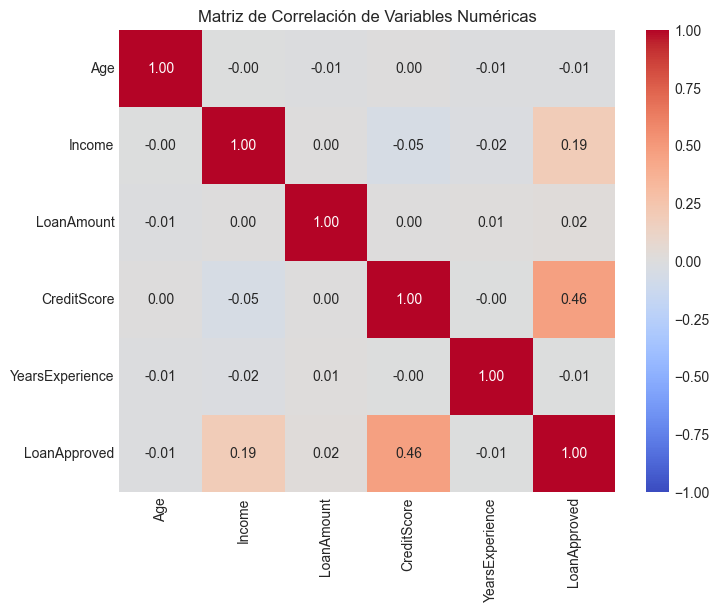

In [13]:
# Filtramos solo las variables numéricas para la correlación
numericas_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8, 6))
# fmt=".2f" muestra solo dos decimales
sns.heatmap(numericas_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

## Fase 2: Limpieza de Datos
En esta sección solucionaremos los problemas de calidad de datos detectados:
1. **Valores ilógicos:** Transformaremos los ingresos y montos negativos a positivos (asumiendo que fueron errores de tipeo al ingresar la data).
2. **Valores nulos:** Imputaremos los valores numéricos faltantes usando la mediana (para que no se afecte por valores atípicos) y las variables categóricas con la moda (el valor más frecuente).

In [14]:
print(f"Filas antes de limpieza: {df.shape[0]}")

# 1. Corregir valores negativos (Aplicamos valor absoluto)
df['Income'] = df['Income'].abs()
df['LoanAmount'] = df['LoanAmount'].abs()

# 2. Imputar nulos en variables numéricas (con la mediana)
df['Income'] = df['Income'].fillna(df['Income'].median())
df['CreditScore'] = df['CreditScore'].fillna(df['CreditScore'].median())

# 3. Imputar nulos en variables categóricas (con la moda)
# mode()[0] extrae el primer valor más repetido
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])

print("\nRevisión final de nulos:")
print(df.isnull().sum())

# Verificamos que ya no existan valores negativos
print(f"\nIngresos negativos restantes: {df[df['Income'] < 0].shape[0]}")

Filas antes de limpieza: 5000

Revisión final de nulos:
Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64

Ingresos negativos restantes: 0


## Fase 3: Ingeniería de Características (Encoding)
Convertiremos las variables categóricas (texto) en variables numéricas binarias (0 y 1) utilizando la técnica de One-Hot Encoding, para que los modelos de Machine Learning puedan procesarlas correctamente. Para evitar la multicolinealidad (la trampa de las variables ficticias), eliminaremos la primera categoría generada de cada variable.

In [15]:
# 1. Definir las columnas de texto
columnas_categoricas = ['Gender', 'Education', 'City', 'EmploymentType']

# 2. Aplicar One-Hot Encoding
# drop_first=True evita redundancia (si no es hombre, lógicamente es mujer, no necesitamos 2 columnas)
df_procesado = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# 3. Convertir a formato numérico (pandas a veces genera True/False, queremos 1/0)
# Convertimos todo el dataframe a tipo numérico (float/int)
for col in df_procesado.select_dtypes(include=['bool']).columns:
    df_procesado[col] = df_procesado[col].astype(int)

print(f"Dimensiones originales: {df.shape}")
print(f"Nuevas dimensiones tras el encoding: {df_procesado.shape}")

# Verificamos que todas las columnas sean numéricas ahora
print("\nTipos de datos actuales:")
print(df_procesado.dtypes.value_counts())

# Vista rápida
display(df_procesado.head(3))

Dimensiones originales: (5000, 10)
Nuevas dimensiones tras el encoding: (5000, 15)

Tipos de datos actuales:
int64      12
float64     3
Name: count, dtype: int64


,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved,Gender_Male,Education_High School,Education_Masters,Education_PhD,City_Houston,City_New York,City_San Francisco,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353.0,31258.0,675.0,20,0,0,1,0,0,1,0,0,0,1
1,69,57462.0,23262.0,586.0,6,0,1,1,0,0,0,0,1,1,0
2,46,44219.0,26530.0,781.0,26,1,1,0,0,1,1,0,0,1,0


## Fase 4: Exportación de Datos
Guardaremos el dataset procesado y limpio para utilizarlo en el entrenamiento de los modelos en el siguiente notebook.

In [16]:
# Guardar el nuevo dataframe en la carpeta data
# index=False evita que se guarde una columna extra con el número de fila
ruta_guardado = '../data/credit_risk_dataset_limpio.csv'
df_procesado.to_csv(ruta_guardado, index=False)

print(f"¡Éxito! Dataset limpio guardado en: {ruta_guardado}")

¡Éxito! Dataset limpio guardado en: ../data/credit_risk_dataset_limpio.csv
